In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

from tensorflow import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.preprocessing import image_dataset_from_directory

import os
import matplotlib.image as mpimg


In [ ]:
!pip install kaggle

In [ ]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

100% 2.28G/2.29G [00:17<00:00, 109MB/s]
100% 2.29G/2.29G [00:17<00:00, 139MB/s]


In [ ]:
# Dataset Link- https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
import zipfile
zip_ref = zipfile.ZipFile('/content/chest-xray-pneumonia.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()


In [ ]:
path = '/content/chest_xray/train'
classes = os.listdir(path)
print(classes)


['NORMAL', 'PNEUMONIA']


In [ ]:
# Define the directories for the X-ray images
PNEUMONIA_dir = os.path.join(path + '/' + classes[0])
NORMAL_dir = os.path.join(path + '/' + classes[1])

# Create lists of the file names in each directory
pneumonia_names = os.listdir(PNEUMONIA_dir)
normal_names = os.listdir(NORMAL_dir)

print('There are ', len(pneumonia_names),
	'images of pneumonia infected in training dataset')
print('There are ', len(normal_names), 'normal images in training dataset')


There are  1341 images of pneumonia infected in training dataset
There are  3875 normal images in training dataset


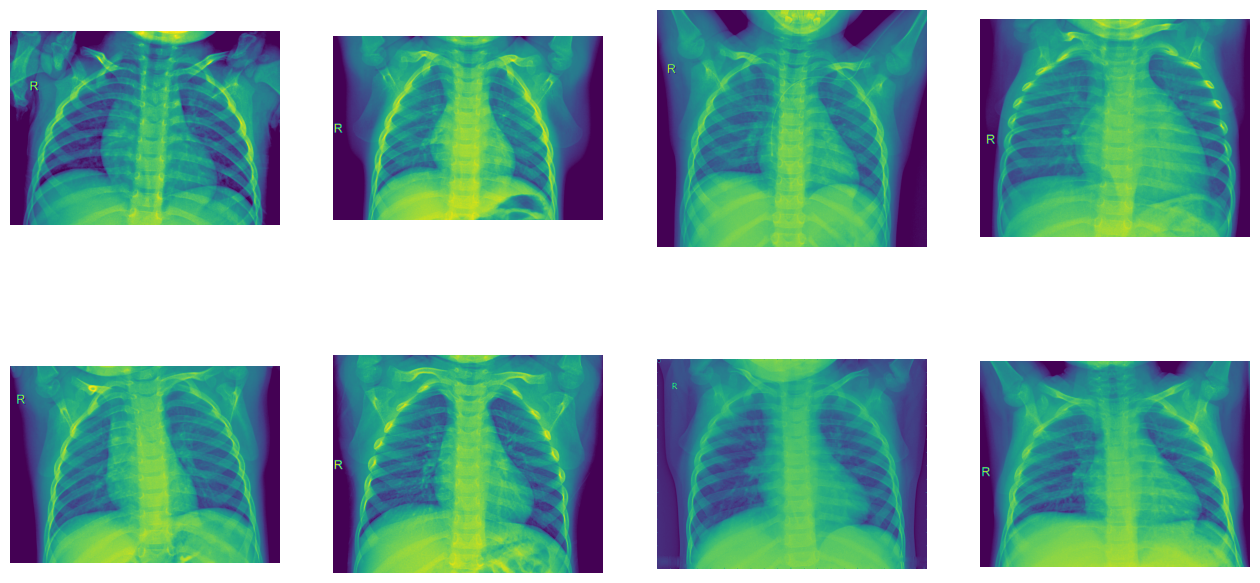

In [ ]:
# Set the figure size
fig = plt.gcf()
fig.set_size_inches(16, 8)

# Select the starting index for the images to display
pic_index = 210

# Create lists of the file paths for the 16 images to display
pneumonia_images = [os.path.join(PNEUMONIA_dir, fname)
					for fname in pneumonia_names[pic_index-8:pic_index]]
# Loop through the image paths and display each image in a subplot
for i, img_path in enumerate(pneumonia_images):
	sp = plt.subplot(2, 4, i+1)
	sp.axis('Off')

	# Read in the image using Matplotlib's imread() function
	img = mpimg.imread(img_path)
	plt.imshow(img)

# Display the plot with the 16 images in a 4x4
plt.show()


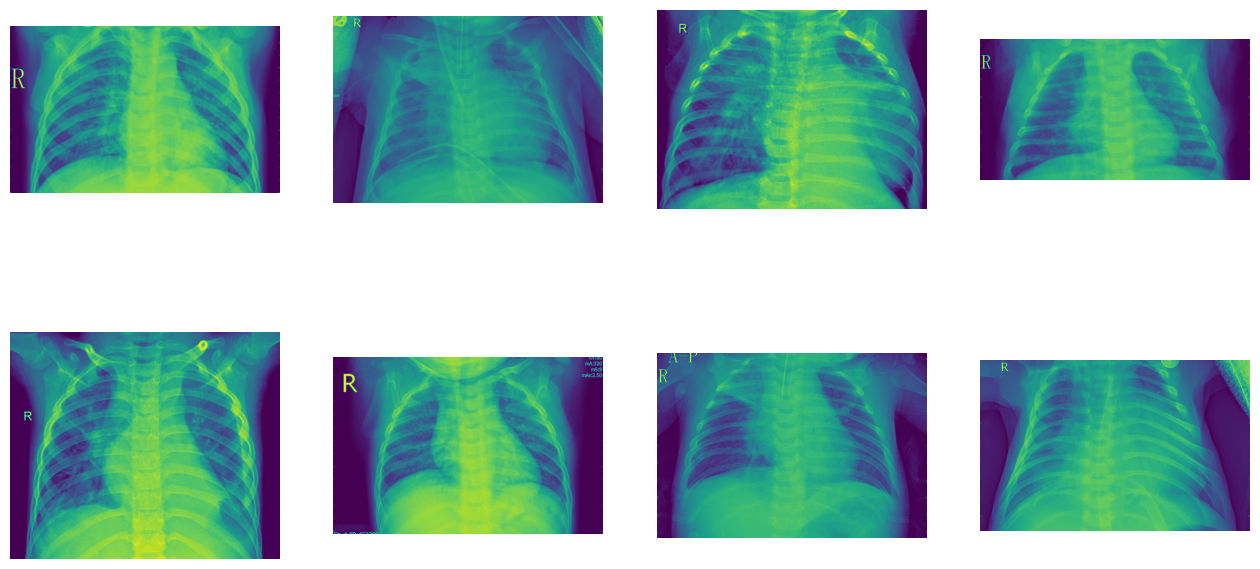

In [ ]:
# Set the figure size
fig = plt.gcf()
fig.set_size_inches(16, 8)

# Select the starting index for the images to display
pic_index = 210

# Create lists of the file paths for the 16 images to display
normal_images = [os.path.join(NORMAL_dir, fname)
			for fname in normal_names[pic_index-8:pic_index]]
# Loop through the image paths and display each image in a subplot
for i, img_path in enumerate(normal_images):
	sp = plt.subplot(2, 4, i+1)
	sp.axis('Off')

	# Read in the image using Matplotlib's imread() function
	img = mpimg.imread(img_path)
	plt.imshow(img)
plt.title(" ")
# Display the plot with the 16 images in a 4x4 grid
plt.show()


In [ ]:
Train = keras.utils.image_dataset_from_directory(
	directory='/content/chest_xray/chest_xray/train',
	labels="inferred",
	label_mode="categorical",
	batch_size=32,
	image_size=(256, 256))
Test = keras.utils.image_dataset_from_directory(
	directory='/content/chest_xray/chest_xray/test',
	labels="inferred",
	label_mode="categorical",
	batch_size=32,
	image_size=(256, 256))
Validation = keras.utils.image_dataset_from_directory(
	directory='/content/chest_xray/chest_xray/val',
	labels="inferred",
	label_mode="categorical",
	batch_size=32,
	image_size=(256, 256))


Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Found 16 files belonging to 2 classes.


In [ ]:
model = tf.keras.models.Sequential([
	layers.Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)),
	layers.MaxPooling2D(2, 2),
	layers.Conv2D(64, (3, 3), activation='relu'),
	layers.MaxPooling2D(2, 2),
	layers.Conv2D(64, (3, 3), activation='relu'),
	layers.MaxPooling2D(2, 2),
	layers.Conv2D(64, (3, 3), activation='relu'),
	layers.MaxPooling2D(2, 2),

	layers.Flatten(),
	layers.Dense(512, activation='relu'),
	layers.BatchNormalization(),
	layers.Dense(512, activation='relu'),
	layers.Dropout(0.1),
	layers.BatchNormalization(),
	layers.Dense(512, activation='relu'),
	layers.Dropout(0.2),
	layers.BatchNormalization(),
	layers.Dense(512, activation='relu'),
	layers.Dropout(0.2),
	layers.BatchNormalization(),
	layers.Dense(2, activation='sigmoid')
])


In [ ]:
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 62, 62, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 64)        36928     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 30, 30, 64)        0

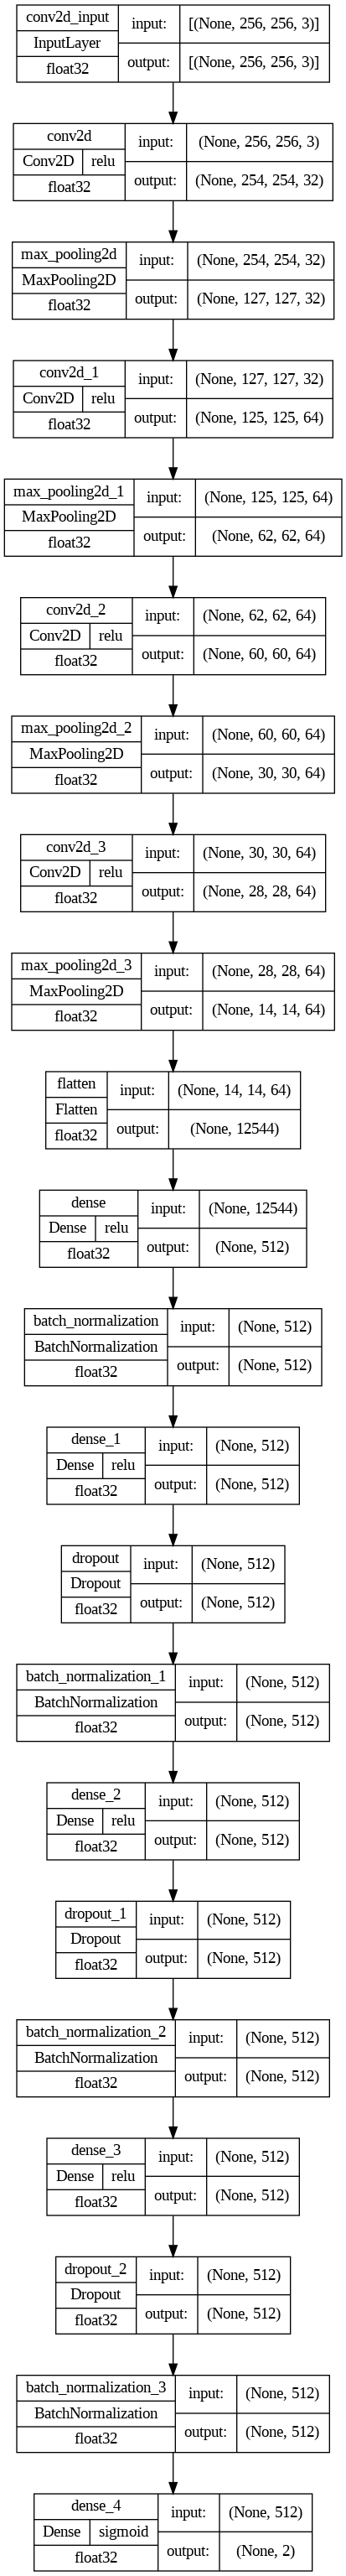

In [ ]:
# Plot the keras model
keras.utils.plot_model(
	model,
	# show the shapes of the input/output tensors of each layer
	show_shapes=True,
	# show the data types of the input/output tensors of each layer
	show_dtype=True,
	# show the activations of each layer in the output graph
	show_layer_activations=True
)


In [ ]:
model.compile(
	# specify the loss function to use during training
	loss='binary_crossentropy',
	# specify the optimizer algorithm to use during training
	optimizer='adam',
	# specify the evaluation metrics to use during training
	metrics=['accuracy']
)


In [ ]:
history = model.fit(Train,
		epochs=20,
		validation_data=Validation)


Epoch 1/20
163/163 [==============================] - 41s 238ms/step - loss: 0.0736 - accuracy: 0.9728 - val_loss: 8.4750 - val_accuracy: 0.5000
Epoch 2/20
163/163 [==============================] - 42s 249ms/step - loss: 0.1292 - accuracy: 0.9538 - val_loss: 5.3966 - val_accuracy: 0.5000
Epoch 3/20
163/163 [==============================] - 39s 232ms/step - loss: 0.0804 - accuracy: 0.9714 - val_loss: 7.2901 - val_accuracy: 0.5000
Epoch 4/20
163/163 [==============================] - 39s 232ms/step - loss: 0.0712 - accuracy: 0.9737 - val_loss: 2.6793 - val_accuracy: 0.5625
Epoch 5/20
163/163 [==============================] - 38s 224ms/step - loss: 0.0621 - accuracy: 0.9758 - val_loss: 1.2704 - val_accuracy: 0.6250
Epoch 6/20
163/163 [==============================] - 38s 223ms/step - loss: 0.0531 - accuracy: 0.9824 - val_loss: 2.1803 - val_accuracy: 0.5625
Epoch 7/20
163/163 [==============================] - 39s 223ms/step - loss: 0.0532 - accuracy: 0.9820 - val_loss: 0.2599 - val_ac

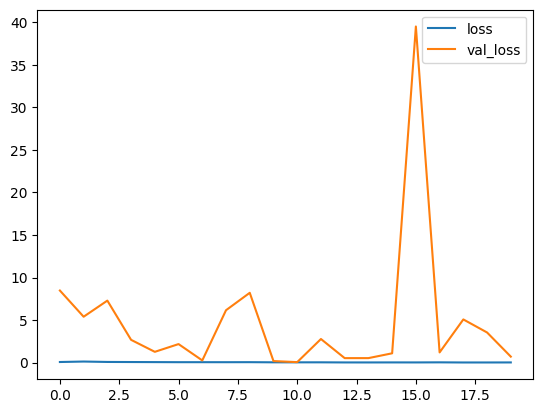

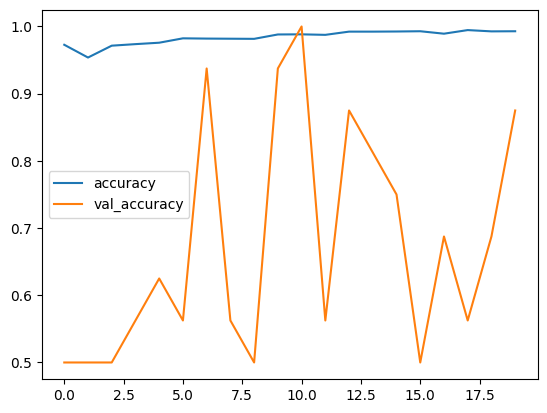

In [ ]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
history_df.loc[:, ['accuracy', 'val_accuracy']].plot()
plt.show()


In [ ]:
loss, accuracy = model.evaluate(Test)
print('The accuracy of the model on test dataset is',
	np.round(accuracy*100))



20/20 [==============================] - 4s 110ms/step - loss: 2.1711 - accuracy: 0.7436
The accuracy of the model on test dataset is 74.0


1/1 [==============================] - 0s 391ms/step
Normal


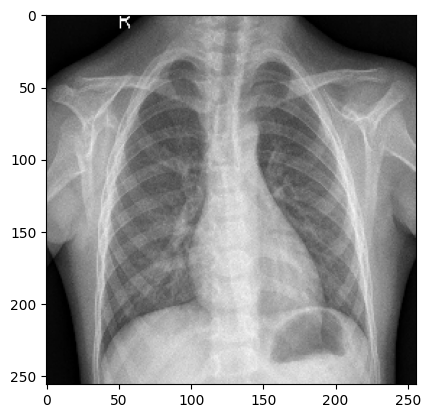

In [ ]:
# Load the image from the directory
# "/content/chest_xray/chest_xray/test/NORMAL/IM-0010-0001.jpeg"
# with the target size of (256, 256)
test_image = tf.keras.utils.load_img(
	"/content/chest_xray/chest_xray/test/NORMAL/IM-0010-0001.jpeg",
	target_size=(256, 256))

# Display the loaded image
plt.imshow(test_image)

# Convert the loaded image into a NumPy array and
# expand its dimensions to match the expected input shape of the model
test_image = tf.keras.utils.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis=0)

# Use the trained model to make a prediction on the input image
result = model.predict(test_image)

# Extract the probability of the input image belonging
# to each class from the prediction result
class_probabilities = result[0]

# Determine the class with the highest probability and print its label
if class_probabilities[0] > class_probabilities[1]:
	print("Normal")
else:
	print("Pneumonia")


1/1 [==============================] - 0s 19ms/step
Pneumonia


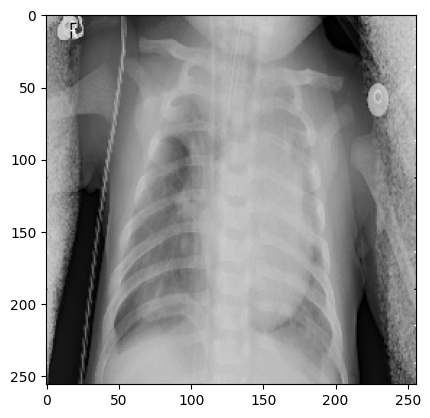

In [ ]:
# Load the image from the directory
# "/content/chest_xray/chest_xray/test/N
# ORMAL/IM-0010-0001.jpeg" with the target size of (256, 256)
test_image = tf.keras.utils.load_img(
	"/content/chest_xray/chest_xray/test/PNEUMONIA/person100_bacteria_478.jpeg",
	target_size=(256, 256))

# Display the loaded image
plt.imshow(test_image)

# Convert the loaded image into a NumPy array
# and expand its dimensions to match the
# expected input shape of the model
test_image = tf.keras.utils.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis=0)

# Use the trained model to make a prediction on the input image
result = model.predict(test_image)

# Extract the probability of the input
# image belonging to each class from
# the prediction result
class_probabilities = result[0]

# Determine the class with the highest
# probability and print its label
if class_probabilities[0] > class_probabilities[1]:
	print("Normal")
else:
	print("Pneumonia")


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import ResNet50

# Load pre-trained ResNet50 model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Freeze the layers of the pre-trained model
for layer in base_model.layers:
    layer.trainable = False

# Create a new model by adding custom layers on top of ResNet50
model1 = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(2, activation='sigmoid')
])

# Compile the model
model1.compile(optimizer=optimizers.Adam(lr=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model1.summary()


94765736/94765736 [==============================] - 1s 0us/step


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 8, 8, 2048)        23587712  
                                                                 
 flatten_1 (Flatten)         (None, 131072)            0         
                                                                 
 dense_5 (Dense)             (None, 512)               67109376  
                                                                 
 batch_normalization_4 (Bat  (None, 512)               2048      
 chNormalization)                                                
                                                                 
 dropout_3 (Dropout)         (None, 512)               0         
                                                                 
 dense_6 (Dense)             (None, 2)                 1026      
                                                      

In [ ]:
history1 = model1.fit(Train,
		epochs=10,
		validation_data=Validation)


Epoch 1/10
163/163 [==============================] - 53s 267ms/step - loss: 0.1424 - accuracy: 0.9557 - val_loss: 0.0537 - val_accuracy: 1.0000
Epoch 2/10
163/163 [==============================] - 42s 248ms/step - loss: 0.0424 - accuracy: 0.9887 - val_loss: 0.0609 - val_accuracy: 1.0000
Epoch 3/10
163/163 [==============================] - 41s 231ms/step - loss: 0.0223 - accuracy: 0.9935 - val_loss: 0.0143 - val_accuracy: 1.0000
Epoch 4/10
163/163 [==============================] - 40s 232ms/step - loss: 0.0082 - accuracy: 0.9987 - val_loss: 0.1837 - val_accuracy: 0.8750
Epoch 5/10
163/163 [==============================] - 40s 237ms/step - loss: 0.0095 - accuracy: 0.9983 - val_loss: 0.0788 - val_accuracy: 0.9375
Epoch 6/10
163/163 [==============================] - 40s 236ms/step - loss: 0.0052 - accuracy: 0.9985 - val_loss: 0.1990 - val_accuracy: 0.8750
Epoch 7/10
163/163 [==============================] - 40s 238ms/step - loss: 0.0085 - accuracy: 0.9975 - val_loss: 0.2695 - val_ac

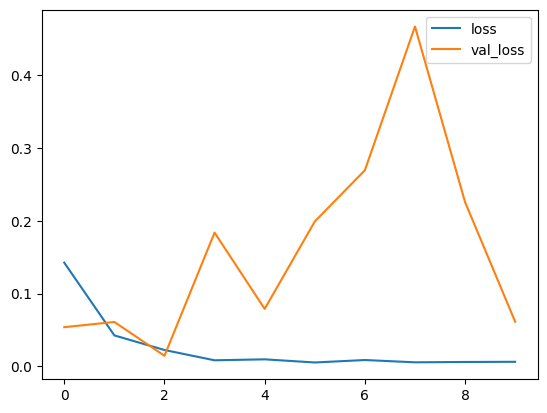

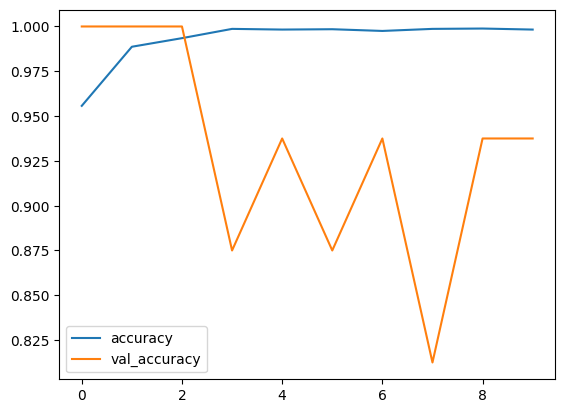

In [ ]:
history_df1= pd.DataFrame(history1.history)
history_df1.loc[:, ['loss', 'val_loss']].plot()
history_df1.loc[:, ['accuracy', 'val_accuracy']].plot()
plt.show()


In [ ]:
loss, accuracy = model1.evaluate(Test)
print('The accuracy of the model on test dataset is',
	accuracy*100)



20/20 [==============================] - 6s 203ms/step - loss: 0.9345 - accuracy: 0.8253
The accuracy of the model on test dataset is 82.53205418586731


58889256/58889256 [==============================] - 0s 0us/step


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 8, 8, 512)         14714688  
                                                                 
 flatten_2 (Flatten)         (None, 32768)             0         
                                                                 
 dense_7 (Dense)             (None, 512)               16777728  
                                                                 
 batch_normalization_5 (Bat  (None, 512)               2048      
 chNormalization)                                                
                                                                 
 dropout_4 (Dropout)         (None, 512)               0         
                                                                 
 dense_8 (Dense)             (None, 2)                 1026      
                                                      

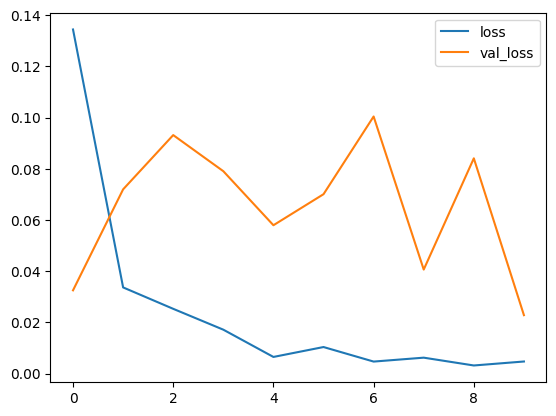

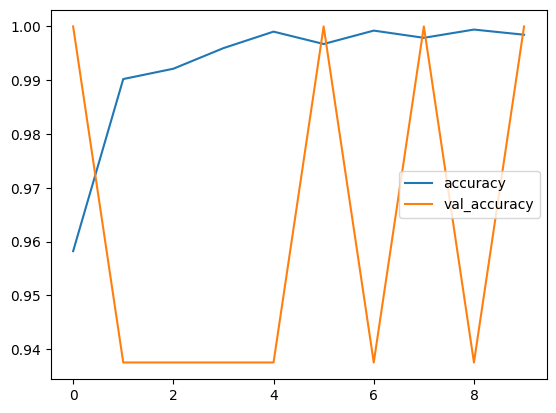

In [ ]:
from tensorflow.keras.applications import VGG16
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers


base_model2= VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Freeze the layers of the pre-trained model
for layer in base_model2.layers:
    layer.trainable = False

# Create a new model by adding custom layers on top of ResNet50
model2 = models.Sequential([
    base_model2,
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(2, activation='sigmoid')
])

# Compile the model
model2.compile(optimizer=optimizers.Adam(lr=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model2.summary()
history2= model2.fit(Train,
		epochs=10,
		validation_data=Validation)
loss, accuracy = model2.evaluate(Test)
print('The accuracy of the model on test dataset is',
	accuracy*100)
history_df2= pd.DataFrame(history2.history)
history_df2.loc[:, ['loss', 'val_loss']].plot()
history_df2.loc[:, ['accuracy', 'val_accuracy']].plot()
plt.show()




87910968/87910968 [==============================] - 1s 0us/step


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 6, 6, 2048)        21802784  
                                                                 
 flatten_3 (Flatten)         (None, 73728)             0         
                                                                 
 dense_9 (Dense)             (None, 512)               37749248  
                                                                 
 batch_normalization_100 (B  (None, 512)               2048      
 atchNormalization)                                              
                                                                 
 dropout_5 (Dropout)         (None, 512)               0         
                                                                 
 dense_10 (Dense)            (None, 2)                 1026      
                                                      

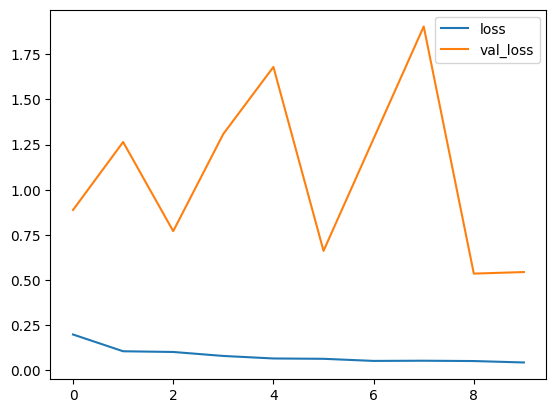

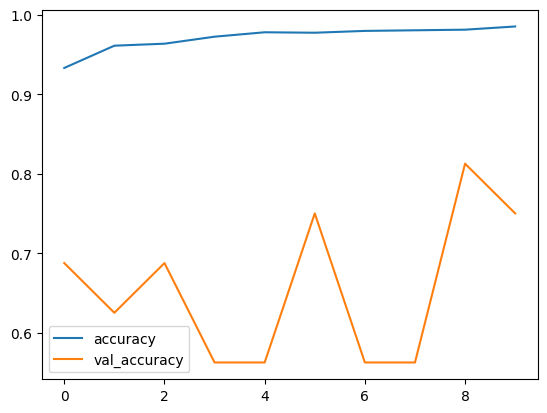

In [ ]:
from tensorflow.keras.applications import InceptionV3
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers


base_model3= InceptionV3(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Freeze the layers of the pre-trained model
for layer in base_model3.layers:
    layer.trainable = False

# Create a new model by adding custom layers on top of ResNet50
model3 = models.Sequential([
    base_model3,
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(2, activation='sigmoid')
])

# Compile the model
model3.compile(optimizer=optimizers.Adam(lr=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model3.summary()
history3= model3.fit(Train,
		epochs=10,
		validation_data=Validation)
loss, accuracy = model2.evaluate(Test)
print('The accuracy of the model on test dataset is',
	accuracy*100)
history_df3= pd.DataFrame(history3.history)
history_df3.loc[:, ['loss', 'val_loss']].plot()
history_df3.loc[:, ['accuracy', 'val_accuracy']].plot()
plt.show()


